Attaching SeuratObject

载入需要的程辑包：dplyr


载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


载入需要的程辑包：igraph


载入程辑包：‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


载入需要的程辑包：ggplot2

as(<dgTMatrix>, "dgCMatrix")不再有用。
请用'as(., "CsparseMatrix")'。
见help("Deprecated")和help("Matrix-deprecated")。



[1] "Create a CellChat object from a data matrix"


Warning message in createCellChat(object = data.input, meta = meta, group.by = "labels"):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Epithelial cancer 1, Fibroblast, B cell, Epithelial cancer 2, Macrophage 1, T cell 2, T cell 1, T cell 3, Macrophage 4, Epithelial cell, Macrophage 3, Endothelial cell, Macrophage 2, Dendritic cell 2, Dendritic cell 1 
Rows: 3,379
Columns: 28
$ interaction_name         <chr> "TGFB1_TGFBR1_TGFBR2", "TGFB2_TGFBR1_TGFBR2",…
$ pathway_name             <chr> "TGFb", "TGFb", "TGFb", "TGFb", "TGFb", "TGFb…
$ ligand                   <chr> "Tgfb1", "Tgfb2", "Tgfb3", "Tgfb1", "Tgfb1", …
$ receptor                 <chr> "TGFbR1_R2", "TGFbR1_R2", "TGFbR1_R2", "ACVR1…
$ agonist                  <chr> "TGFb agonist", "TGFb agonist", "TGFb agonist…
$ antagonist               <chr> "TGFb antagonist", "TGFb antagonist", "TGFb a…
$ co_A_receptor            <chr> "", "", "", "", "", "", "", "", "", "", "", "…
$ co_I_receptor            <chr> "TGFb inhibition receptor", "TGFb inhibition …
$ annotation        

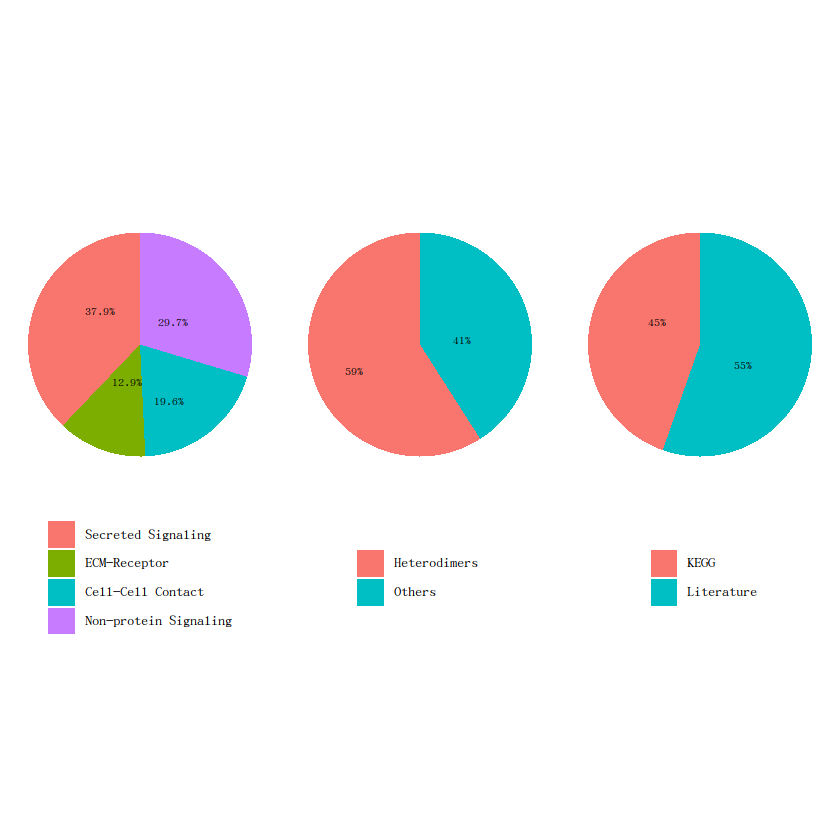

In [1]:
library(Seurat)
library(CellChat)
library(patchwork)
options(stringsAsFactors = FALSE)


RNA_count <- Matrix::readMM("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Gene_Cell.mtx")
Gene_names <- read.csv("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Gene_names.tsv", header = FALSE, sep = ",")
Cell_names <- read.table("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Cell_names.tsv", header = FALSE, sep = ",")
Cell_types <- read.table("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Cell_types.tsv", header = FALSE, sep = ",")


RNA_count <- as(RNA_count, "dgCMatrix")
colnames(RNA_count) <- Cell_names$V1
rownames(RNA_count) <- Gene_names$V1
rownames(Cell_types) <- Cell_names$V1
rownames(Gene_names) <- Gene_names$V1
names(Gene_names)<-c("gene_short_name")


SeuratObj <- CreateSeuratObject(counts = RNA_count)
SeuratObj$cell_types <- Cell_types$V1
SeuratObj<- NormalizeData(SeuratObj, normalization.method = "LogNormalize", scale.factor = 10000)
Idents(SeuratObj) <- SeuratObj@meta.data$cell_types
data.input <- SeuratObj[["RNA"]]@data
labels <- Idents(SeuratObj)
meta <- data.frame(labels = labels, row.names = names(labels))
cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")


CellChatDB <- CellChatDB.mouse
showDatabaseCategory(CellChatDB)
dplyr::glimpse(CellChatDB$interaction)
CellChatDB.use <- subsetDB(CellChatDB)
cellchat@DB <- CellChatDB.use

In [2]:
options(future.globals.maxSize = 600 * 1024 ^ 2)
cellchat <- subsetData(cellchat)
future::plan("multisession", workers = 4)
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)


cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
df.net <- subsetCommunication(cellchat)
# write.csv(df.net, file = ""./ComicGTN/data/Mouse_retina/Cellchat_net.csv", row.names = FALSE)

The number of highly variable ligand-receptor pairs used for signaling inference is 1838 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-02-27 16:38:46]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-02-27 16:42:55]"


In [13]:
cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)
groupSize <- as.numeric(table(cellchat@idents))


for (i in 1) {
    ragg::agg_png("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/1.png",res = 600, width = 3600, height = 3600)
    par(mfrow = c(1,1), xpd = TRUE)
    netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= T, 
                              vertex.label.cex = 0.001, title.name = "Number of interactions")
    dev.off()
    }


 for (i in 1) {
    ragg::agg_png("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/2.png",res = 600, width = 3600, height = 3600)
    par(mfrow = c(1,1), xpd = TRUE)
    netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= T, 
                              vertex.label.cex = 0.001, title.name = "Interaction weights/strength")
    dev.off()
    }

In [4]:
cellchat@netP$pathways
pathways.show <- c("CD45") 
vertex.receiver = seq(0, 15)
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)


for (i in 1) {
    ragg::agg_png("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/3.png",res = 600, width = 3600, height = 3600)
    par(mfrow = c(1,1), xpd = TRUE)
    netVisual_aggregate(cellchat, signaling = pathways.show, layout = "chord")
    dev.off()
    }


pathways.show <- c("SPP1") 
vertex.receiver = seq(0, 15)
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)


for (i in 1) {
    ragg::agg_png("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/4.png",res = 600, width = 3600, height = 3600)
    par(mfrow = c(1,1), xpd = TRUE)
    netVisual_aggregate(cellchat, signaling = pathways.show, layout = "chord")
    dev.off()
    }


write.table(x = cellchat@net$count, file = "./ComicGTN_reproducibility/Data/Mouse_breast_tumor/CellChat_count.csv", sep = ",", row.names = TRUE, col.names = TRUE)
write.table(x = cellchat@net$weight, file = "./ComicGTN_reproducibility/Data/Mouse_breast_tumor/CellChat_weight.csv", sep = ",", row.names = TRUE, col.names = TRUE)